In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
sns.set_theme(style="whitegrid")
df = pd.read_csv("Train.csv")
print("Dataset Loaded Successfully")
print("Shape :", df.shape)
display(df.sample(5))

Dataset Loaded Successfully
Shape : (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
8878,8879,C,Road,4,1,271,5,medium,F,3,1328,0
4167,4168,B,Ship,3,2,231,3,low,F,5,5046,0
4539,4540,B,Ship,2,4,255,7,low,M,10,5875,0
8819,8820,F,Ship,5,4,242,5,low,M,1,1571,1
7375,7376,F,Road,3,1,194,2,medium,F,1,5931,0


In [2]:
def prepare_features(dataframe):
    temp_df = dataframe.copy()
    # remove identifier
    if "ID" in temp_df.columns:
        temp_df.drop("ID", axis=1, inplace=True)
    target = "Reached.on.Time_Y.N"
    X_data = temp_df.drop(columns=[target])
    y_data = temp_df[target]
    return X_data, y_data
X, y = prepare_features(df)
print("Feature Columns:", X.columns.tolist())

Feature Columns: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']


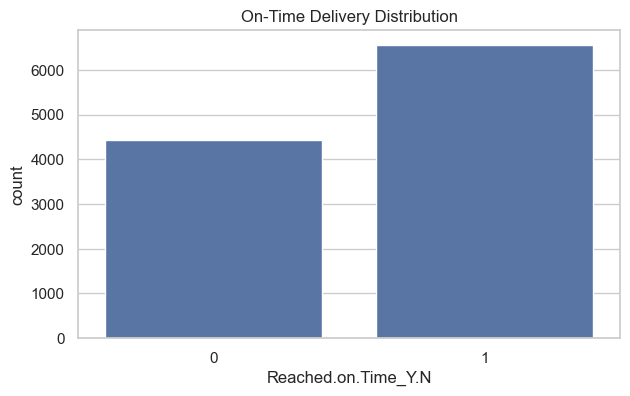

In [6]:
plt.figure(figsize=(7,4))
sns.countplot(x=y)
plt.title("On-Time Delivery Distribution")
plt.show()

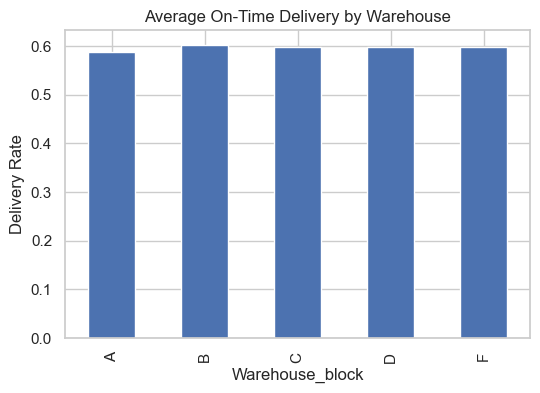

In [8]:
warehouse_summary = df.groupby("Warehouse_block")["Reached.on.Time_Y.N"].mean()

warehouse_summary.plot(kind="bar", figsize=(6,4))
plt.title("Average On-Time Delivery by Warehouse")
plt.ylabel("Delivery Rate")
plt.show()